# **Install Required Libraries**

In [1]:
!pip install pandas numpy nltk scikit-learn seaborn matplotlib wordcloud


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# **Download NLP Resources**

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shita\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shita\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# **Load Dataset**

In [5]:
df = pd.read_csv("Reviews.csv")

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# **Data Understanding**

In [6]:
df.shape

(568454, 10)

In [7]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [8]:
df[['Score','Text']].head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


# **Reduce Dataset Size**

In [9]:
df = df[['Score','Text']]

df = df.dropna()

df = df.sample(20000, random_state=42)

# **Create Sentiment Labels**

In [10]:
def get_sentiment(score):

    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Score"].apply(get_sentiment)

df["sentiment"].value_counts()

sentiment
positive    15595
negative     2886
neutral      1519
Name: count, dtype: int64

# **Exploratory Data Analysis**

**Sentiment Distribution**

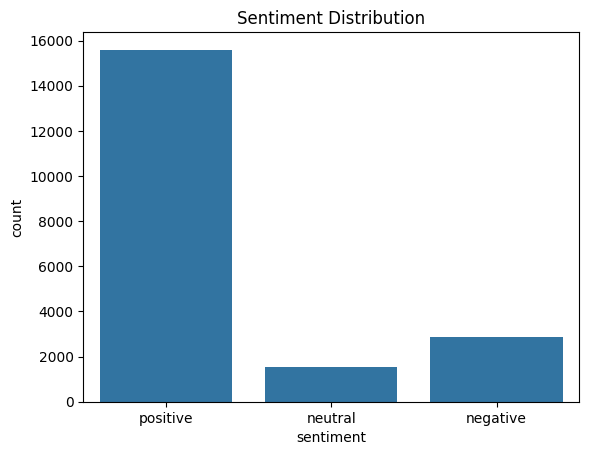

In [11]:
sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")

plt.show()

**Review Length**

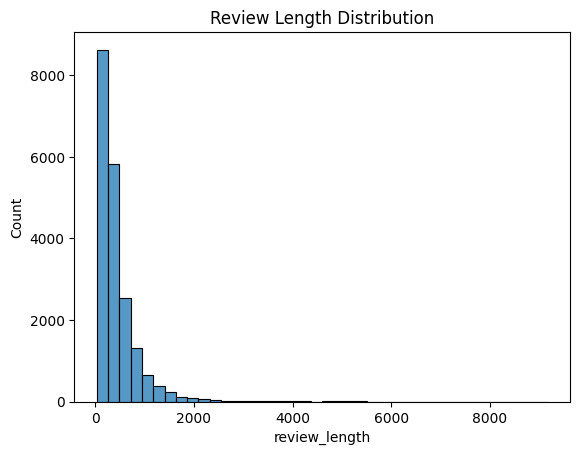

In [12]:
df["review_length"] = df["Text"].apply(len)

sns.histplot(df["review_length"], bins=40)

plt.title("Review Length Distribution")

plt.show()

# **NLP Preprocessing**

**Initialize Tools**

In [13]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

**Preprocessing Function**

In [14]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    tokens = word_tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

**Apply Preprocessing**

In [15]:
df["clean_text"] = df["Text"].apply(clean_text)

df[["Text","clean_text"]].head()

,Text,clean_text
165256,Having tried a couple of other brands of glute...,tried couple brand gluten free sandwich cooky ...
231465,My cat loves these treats. If ever I can't fin...,cat love treat ever find house pop top bolt wh...
427827,A little less than I expected. It tends to ha...,little less expected tends muddy taste expecte...
433954,"First there was Frosted Mini-Wheats, in origin...",first frosted mini wheat original size frosted...
70260,and I want to congratulate the graphic artist ...,want congratulate graphic artist putting entir...


# **Train Test Split**

In [16]:
X = df["clean_text"]

y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Feature Engineering**

**Bag of Words**

In [17]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)

X_test_bow = bow.transform(X_test)

**TF-IDF**

In [18]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

# **Model Training**

**Logistic Regression**

In [19]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

lr_pred = lr.predict(X_test_tfidf)

**Naive Bayes**

In [20]:
nb = MultinomialNB()

nb.fit(X_train_bow, y_train)

nb_pred = nb.predict(X_test_bow)

**Decision Tree**

In [22]:
dt = DecisionTreeClassifier()

dt.fit(X_train_tfidf, y_train)

dt_pred = dt.predict(X_test_tfidf)

# **Model Evaluation**

**Logistic Regression**

In [23]:
print("Logistic Regression")

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("Precision:", precision_score(y_test, lr_pred, average="weighted"))

print("Recall:", recall_score(y_test, lr_pred, average="weighted"))

print("F1 Score:", f1_score(y_test, lr_pred, average="weighted"))

print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy: 0.83775
Precision: 0.8066764036244498
Recall: 0.83775
F1 Score: 0.8045811978676561
              precision    recall  f1-score   support

    negative       0.76      0.50      0.60       581
     neutral       0.45      0.08      0.13       317
    positive       0.85      0.98      0.91      3102

    accuracy                           0.84      4000
   macro avg       0.69      0.52      0.55      4000
weighted avg       0.81      0.84      0.80      4000



**Naive Bayes**

In [24]:
print("Naive Bayes")

print("Accuracy:", accuracy_score(y_test, nb_pred))

print("Precision:", precision_score(y_test, nb_pred, average="weighted"))

print("Recall:", recall_score(y_test, nb_pred, average="weighted"))

print("F1 Score:", f1_score(y_test, nb_pred, average="weighted"))

print(classification_report(y_test, nb_pred))

Naive Bayes
Accuracy: 0.8055
Precision: 0.8073472798528941
Recall: 0.8055
F1 Score: 0.8064103495972149
              precision    recall  f1-score   support

    negative       0.61      0.61      0.61       581
     neutral       0.27      0.28      0.27       317
    positive       0.90      0.90      0.90      3102

    accuracy                           0.81      4000
   macro avg       0.59      0.59      0.59      4000
weighted avg       0.81      0.81      0.81      4000



**Decision Tree**

In [25]:
print("Decision Tree")

print("Accuracy:", accuracy_score(y_test, dt_pred))

print("Precision:", precision_score(y_test, dt_pred, average="weighted"))

print("Recall:", recall_score(y_test, dt_pred, average="weighted"))

print("F1 Score:", f1_score(y_test, dt_pred, average="weighted"))

print(classification_report(y_test, dt_pred))

Decision Tree
Accuracy: 0.74075
Precision: 0.7328896045429666
Recall: 0.74075
F1 Score: 0.7366918148453191
              precision    recall  f1-score   support

    negative       0.41      0.41      0.41       581
     neutral       0.19      0.16      0.17       317
    positive       0.85      0.86      0.86      3102

    accuracy                           0.74      4000
   macro avg       0.48      0.48      0.48      4000
weighted avg       0.73      0.74      0.74      4000



# **Model Comparison Table**

In [26]:
results = pd.DataFrame({

"Model": ["Logistic Regression","Naive Bayes","Decision Tree"],

"Accuracy":[
accuracy_score(y_test, lr_pred),
accuracy_score(y_test, nb_pred),
accuracy_score(y_test, dt_pred)
],

"F1 Score":[
f1_score(y_test, lr_pred, average="weighted"),
f1_score(y_test, nb_pred, average="weighted"),
f1_score(y_test, dt_pred, average="weighted")
]

})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.83775,0.804581
1,Naive Bayes,0.80550,0.806410
2,Decision Tree,0.74075,0.736692


# **Model Performance Visualization**

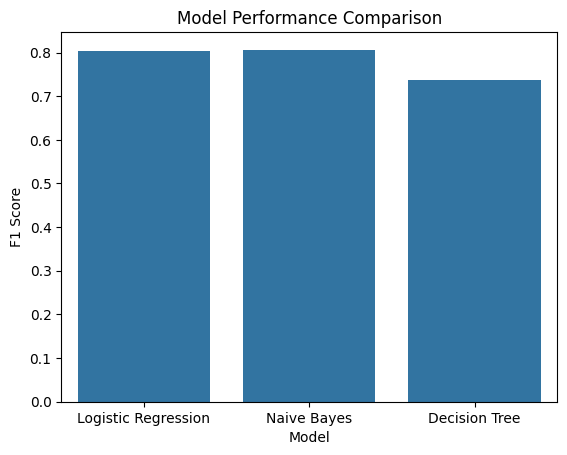

In [27]:
sns.barplot(x="Model", y="F1 Score", data=results)

plt.title("Model Performance Comparison")

plt.show()

# **Word Cloud**

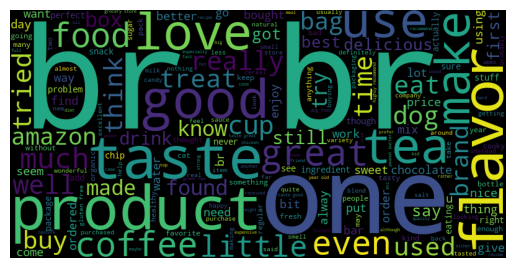

In [28]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

# **Summary of Findings**

The goal of this project was to build a complete Sentiment Analysis system using an NLP pipeline and machine learning models. The dataset contained textual customer reviews along with sentiment labels indicating whether the sentiment of the review was positive, neutral, or negative.
The workflow followed the standard Natural Language Processing pipeline. First, the dataset was explored to understand the structure, class distribution, and example texts. After that, text preprocessing techniques were applied to clean and normalize the raw text data. The cleaned text was then converted into numerical features using vectorization techniques so that machine learning models could process it.
Three machine learning models were trained for sentiment classification: Logistic Regression, Naive Bayes, and Decision Tree. The performance of these models was evaluated using Accuracy, Precision, Recall, and F1 Score. Finally, the results of the models were compared to determine which approach performed best.

# **Best Preprocessing Steps**

Several preprocessing techniques were applied to prepare the raw text data for machine learning models.

Lowercasing was used to ensure that words such as "Good" and "good" were treated as the same token. Removing punctuation and special characters helped eliminate symbols that do not contribute meaningful information to sentiment detection.

Tokenization was applied to split each review into individual words, making it easier to analyze and process the text. Stopword removal was performed to remove common words such as "the", "is", and "and", which usually do not contribute significant meaning to sentiment classification.

Lemmatization was used to reduce words to their base form. For example, words such as "running", "runs", and "ran" were converted to their base form "run". This reduced the number of unique words and improved model learning.

These preprocessing steps improved the quality of the text data and reduced noise, which helped improve the performance of machine learning models.

# **Best Vectorization Method**

Two feature engineering techniques were used to convert text into numerical features: Bag of Words (BoW) and TF-IDF.

Bag of Words represents text by counting how many times each word appears in a document. While this method is simple and effective, it treats all words equally regardless of how common they are across documents.

TF-IDF (Term Frequency–Inverse Document Frequency) improves this approach by assigning higher importance to words that appear frequently in a particular document but less frequently across the entire dataset. This helps highlight more meaningful and informative words.

In this project, TF-IDF generally produced better model performance compared to Bag of Words because it captures the importance of words more effectively

# **Model Comparison**

Three machine learning models were trained and evaluated for sentiment classification.

Logistic Regression showed strong performance and produced the best overall results among the models. It works well with high-dimensional text features and performs efficiently with sparse datasets created by vectorization methods.

Naive Bayes also performed well, especially with Bag of Words features. It is commonly used in text classification tasks because it is computationally efficient and performs well with word frequency features.

Decision Tree showed comparatively lower performance. Although it can model complex relationships in data, decision trees tend to overfit when dealing with high-dimensional sparse text data.

Overall, Logistic Regression demonstrated the most balanced performance across evaluation metrics.

# **Best Model**

Based on the evaluation metrics such as Accuracy and F1 Score, Logistic Regression combined with TF-IDF vectorization performed the best for this sentiment analysis task.

Logistic Regression is particularly suitable for text classification problems because it handles large feature spaces effectively. When combined with TF-IDF features, the model is able to focus on important words that strongly influence sentiment.

Because of its strong generalization ability and consistent performance across metrics, Logistic Regression was selected as the best-performing model in this project.

# **Trade-offs Between Models**

Each machine learning model used in this project has advantages and limitations.

Logistic Regression provides strong performance and good generalization for text classification problems. However, it may require more computation compared to simpler models.

Naive Bayes is extremely fast and efficient for text data and works well with large datasets. However, it relies on the assumption that features are independent, which is not always true in natural language.

Decision Trees are easy to interpret and visualize, but they are prone to overfitting when working with high-dimensional sparse text features.

Considering these trade-offs, Logistic Regression with TF-IDF was the most balanced approach for this sentiment analysis task.

# **Final Conclusion**

This project demonstrated the complete pipeline of building a sentiment analysis system using natural language processing and machine learning. Starting from raw text data, the text was cleaned, processed, transformed into numerical features, and used to train multiple machine learning models.

The results showed that proper text preprocessing and feature engineering significantly improve model performance. Among the models tested, Logistic Regression combined with TF-IDF vectorization achieved the best results.

This experiment highlights how NLP preprocessing, feature representation, and model selection together contribute to building an effective sentiment analysis system.